# **Predicción del riesgo de estrés financiero en asalariados de la Comunidad de Madrid**
## **TFM - Máster de Data Science**
### *Pipeline de Modelado*
---

**Inputs:**
- `src/data/02_silver/train_silver.csv` / `test_silver.csv` - split ya realizado en Silver
- `src/data/03_gold/raw/FEATURES_NUtxt` / `FEATURES_CAT.txt` - selección del EDA

**Outputs:**
- `src/data/03_gold/` - datasets preprocesados (train/test × SEL/ALL)
- `src/data/04_modelos/` - preprocessors, modelo final, parámetros Optuna
- `src/img/` - gráficos de evaluación y explicabilidad

---

| Sección | Contenido |
|---------|-----------|
| 0 | Setup y carga |
| 1 | Preprocesado - ColumnTransformer (fit solo en train) |
| 2 | Métrica objetivo |
| 3 | Baseline con cross-validation |
| 4 | GridSearchCV sobre el mejor modelo |
| 5 | Optimización fina con Optuna |
| 6 | Evaluación final sobre test |
| 7 | Feature Importance - LightGBM nativo |
| 8 | Exportación de artefactos |

---
## **0. Setup y carga**


In [1]:
import os
os.chdir('..')
os.getcwd()

'c:\\Users\\sorim\\REPO_somm14\\EVOLVE\\tfm_project\\src'

In [ ]:
import warnings, json, pickle
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from pathlib import Path

from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay, roc_curve, f1_score, auc, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
    )
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
)

os.chdir(Path(os.getcwd()).resolve())

from utils.constants_utils import (
    PATH_TRAIN_SILVER, PATH_TEST_SILVER, PATH_FEAT_NUM, PATH_FEAT_CAT,
    C_NEUTRAL, C0, C1, COLS_LOG1P)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

TARGET = 'estres_financiero_alto'
RANDOM_STATE = 42

# Features que no se integrará en el modelo por porcentaje alto de nulos, 100% de cardinalidad, valores constantes, variantes del target.
FEATURES_DEL = ['motivo_aumento_ingresos', 'motivo_disminucion_ingresos', 'id_hogar', 'id_persona', 'region', 'capacidad_fin_de_mes', 'capacidad_gastos_imprevistos', 'retrasos_facturas', 'retrasos_hipoteca_alquiler', 'retrasos_deudas_no_vivienda']

In [ ]:
#  Carga
train = pd.read_csv(PATH_TRAIN_SILVER, low_memory=False)
test = pd.read_csv(PATH_TEST_SILVER,  low_memory=False)

FEATURES_DEL.append(TARGET)
X_train_raw = train.drop(FEATURES_DEL, axis=1) # Se eliminan por alto porcentaje de nulos
y_train = train[TARGET].astype(int)
X_test_raw = test.drop(FEATURES_DEL, axis=1)
y_test = test[TARGET].astype(int)

print(f'Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}')
print(f'Clase 1 en train: {y_train.mean()*100:.1f}%  |  en test: {y_test.mean()*100:.1f}%')


Train: (2357, 56)  |  Test: (590, 56)
Clase 1 en train: 15.8%  |  en test: 15.8%


In [4]:
#  Lectura de features del EDA
def leer_txt(path):
    with open(path, encoding='utf-8') as f:
        return [x.strip() for x in f.read().split(',') if x.strip()]

FEATURES_NUM = [f for f in leer_txt(PATH_FEAT_NUM) if f in X_train_raw.columns]
FEATURES_CAT = [f for f in leer_txt(PATH_FEAT_CAT) if f in X_train_raw.columns]

print(f'Features EDA - numéricas: {len(FEATURES_NUM)}  categóricas: {len(FEATURES_CAT)}')
print(f'Numéricas: {FEATURES_NUM}')
print(f'Categóricas: {FEATURES_CAT}')

Features EDA - numéricas: 15  categóricas: 23
Numéricas: ['renta_hogar_per_capita', 'gastos_vivienda', 'ratio_carga_vivienda', 'ocupacion_isco08', 'renta_neta_salarial', 'importe_alquiler', 'num_habitaciones', 'anios_experiencia', 'meses_desempleo_ref', 'cuota_hipoteca', 'renta_no_monetaria_salarial', 'meses_desempleo_5anios', 'unidades_consumo', 'horas_semana', 'precariedad_laboral']
Categóricas: ['jornada', 'pais_nacimiento', 'hogar_riesgo_pobreza', 'tipo_vivienda', 'arope_2030', 'expectativa_ingresos_12m', 'regimen_tenencia', 'puede_proteina_2dias', 'carencia_material_social_severa', 'puede_sustituir_muebles', 'puede_vacaciones', 'nivel_estudios', 'estado_salud', 'limitacion_actividad', 'hogar_carencia_material', 'arope_2020', 'sexo', 'tipo_contrato', 'cambio_ingresos_12m', 'baja_intensidad_laboral_2020', 'nacionalidad', 'puede_calefaccion_invierno', 'tipo_hogar']


In [5]:
FEATURES_ALL = FEATURES_NUM.copy()
FEATURES_ALL.extend(FEATURES_CAT)

X_train_sel = train[FEATURES_ALL]

## 1. **Preprocesado - ColumnTransformer**

Se construyen **dos variantes**:
- **SEL** - solo features seleccionadas en el EDA (sin multicolinealidad)
- **ALL** - todas las features disponibles (para comparar en el baseline)

Ambas se ajustan exclusivamente sobre `X_train_raw`.

**Decisiones de preprocesado:**

| Tipo | Transformación | Justificación |
|------|---------------|---------------|
| Numéricas de renta | `log1p` -> `SimpleImputer(median)` -> `StandardScaler` | Skew confirmado en EDA.5 |
| Numéricas resto | `SimpleImputer(median)` -> `StandardScaler` | Centrado para modelos lineales |
| Categóricas nominales | `SimpleImputer(most_frequent)` -> `OHE` | Sin orden semántico |
| Categóricas ordinales | `SimpleImputer(most_frequent)` -> `OrdinalEncoder` | Preserva el orden real |

El preprocesado y el modelo se encapsulan en un único objeto `Pipeline` de sklearn.
Esto garantiza que dentro del CV y del GridSearch, cada fold:
1. Ajusta el `SimpleImputer` solo sobre sus datos de train
2. Ajusta el `StandardScaler` solo sobre sus datos de train
3. Aprende las categorías del `OrdinalEncoder` solo sobre sus datos de train

```
Pipeline([
  ('preprocesado', ColumnTransformer([num, nom, ord])),
  ('modelo',       LGBMClassifier(...))
])
     ↓
cross_validate(pipeline, X_train_raw, y_train, cv=5)
                  ↑
     X_train_raw sin transformar — el pipeline lo transforma
     internamente en cada fold
```


In [6]:
# Variables ordinales con su orden semántico exacto
ORDINAL_VARS = {
    'nivel_estudios':            ['Hasta primaria', 'Secundaria 1a etapa',
                                  'Post-secundaria', 'Superior universitario',
                                  'Master/Doctorado'],
    'estado_salud':              ['Muy malo', 'Malo', 'Regular', 'Bueno', 'Muy bueno'],
    'limitacion_actividad':      ['Gravemente limitado', 'Limitado (no grave)', 'No limitado'],
    'grado_urbanizacion':        ['Zona poco poblada', 'Zona media', 'Zona muy poblada'],
    'cambio_ingresos_12m':       ['Han disminuido', 'Se mantienen', 'Han aumentado'],
    'expectativa_ingresos_12m':  ['Empeorar', 'Mantenerse', 'Mejorar'],
    'carga_prestamos_no_vivienda': ['Una carga pesada', 'Una carga razonable', 'Ninguna carga'],
    'carga_asistencia_medica':   ['Una carga pesada', 'Una carga razonable',
                                  'Ninguna carga', 'No ha utilizado'],
    'carga_asistencia_dental':   ['Una carga pesada', 'Una carga razonable',
                                  'Ninguna carga', 'No ha utilizado'],
    'carga_medicamentos':        ['Una carga pesada', 'Una carga razonable',
                                  'Ninguna carga', 'No ha consumido'],
}

In [36]:
# Función en ámbito raíz — pickle puede serializarla
def log1p_rentas(X):
    X = X.copy().astype(float)
    X[:, IDX_LOG] = np.log1p(np.clip(X[:, IDX_LOG], 0, None))
    return X


def construir_preprocessor(cols_num, cols_cat):
    global IDX_LOG
    IDX_LOG = [cols_num.index(c) for c in COLS_LOG1P if c in cols_num]

    cols_ord = [c for c in cols_cat if c in ORDINAL_VARS]
    cols_nom = [c for c in cols_cat if c not in ORDINAL_VARS]

    pipe_num = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('log1p',   FunctionTransformer(log1p_rentas)),
        ('scaler',  StandardScaler()),
    ])
    pipe_nom = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe',     OneHotEncoder(handle_unknown='ignore',
                                  sparse_output=False, drop='if_binary')),
    ])
    ord_cats = [ORDINAL_VARS[c] for c in cols_ord if c in ORDINAL_VARS]
    pipe_ord = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('enc',     OrdinalEncoder(categories=ord_cats,
                                   handle_unknown='use_encoded_value',
                                   unknown_value=-1)),
    ])
    transformers = []
    if cols_num: transformers.append(('num', pipe_num, cols_num))
    if cols_nom: transformers.append(('nom', pipe_nom, cols_nom))
    if cols_ord: transformers.append(('ord', pipe_ord, cols_ord))
    return ColumnTransformer(transformers=transformers, remainder='drop',
                             verbose_feature_names_out=True)


In [37]:
def construir_pipeline_completo(modelo, cols_num, cols_cat):
    '''
    Encapsula preprocesado + modelo en un único Pipeline.
    Al pasarlo a cross_validate / GridSearchCV, cada fold ajusta
    el preprocesado solo sobre sus datos de train.
    '''
    return Pipeline([
        ('preprocesado', construir_preprocessor(cols_num, cols_cat)),
        ('modelo',       modelo),
    ])

# Verificar que el pipeline se construye correctamente
set_config(display='diagram')

pipe_test = construir_pipeline_completo(
    DummyClassifier(), FEATURES_NUM, FEATURES_CAT)

pipe_test

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesado', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

## **2. Métrica objetivo**

### *ROC-AUC - métrica principal*
Con desbalanceo 1:5, la accuracy es engañosa: un clasificador que siempre predice
"sin estrés" alcanza ~84% sin aprender nada.
**ROC-AUC** mide la capacidad de separar las dos clases a través de todos los
umbrales posibles. Es insensible al desbalanceo y permite comparar modelos
independientemente del umbral elegido.

### *F1-Score clase 1 - métrica secundaria*
Media armónica de precision y recall de la clase "estrés alto".
En contexto de RRHH, un **falso negativo** (empleado en riesgo no detectado)
es más costoso que un falso positivo → se usa `class_weight='balanced'` en todos
los modelos que lo soporten.

### *Validación: StratifiedKFold(n_splits=5)*
Preserva la proporción del target en cada fold.
Resultados reportados como **media ± desviación estándar**.

### *`class_weight='balanced'`*
Compensa el desbalanceo multiplicando el error de la clase minoritaria por el ratio 1:5, sin necesidad de oversampling.


## **3. Baseline con cross-validation (5-fold estratificada)**

El objeto que pasa al `cross_validate` es el **Pipeline completo** (preprocesado + modelo). Cada fold hace `pipeline.fit(X_train_fold)` internamente, lo que garantiza que el imputer y el scaler nunca ven el fold de validación.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())

MODELOS_BASELINE = {
    'LogisticRegression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200, scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE, eval_metric='logloss',
        verbosity=0, n_jobs=-1),
    'LightGBM': LGBMClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}
SCORING = {'roc_auc': 'roc_auc', 'f1': 'f1'}

In [13]:
resultados_cv = []

for variante, X_tr in [('SEL', X_train_sel), ('ALL', X_train_raw)]:
    print(f'\n── Variante {variante} ──')
    cols_num = [col for col in X_tr if X_tr[col].dtypes in [int,float]]
    cols_cat = [col for col in X_tr if col not in cols_num]
    for nombre, modelo in MODELOS_BASELINE.items():
        pipeline = construir_pipeline_completo(
            modelo, cols_num, cols_cat
        )
        scores = cross_validate(
            pipeline, X_tr, y_train,
            cv=cv, scoring=SCORING, n_jobs=-1,
        )
        auc = scores['test_roc_auc']
        f1  = scores['test_f1']
        print(f'  {nombre:<22}  AUC: {auc.mean():.4f} ± {auc.std():.4f}'
              f'   F1: {f1.mean():.4f} ± {f1.std():.4f}')
        resultados_cv.append({
            'variante': variante, 'modelo': nombre,
            'auc_mean': auc.mean(), 'auc_std': auc.std(),
            'f1_mean':  f1.mean(),  'f1_std':  f1.std(),
        })

df_cv = pd.DataFrame(resultados_cv).sort_values('auc_mean', ascending=False)
display(df_cv.round(4))


── Variante SEL ──
  LogisticRegression      AUC: 0.9176 ± 0.0114   F1: 0.6393 ± 0.0179
  RandomForest            AUC: 0.9388 ± 0.0143   F1: 0.6683 ± 0.0337
  XGBoost                 AUC: 0.9362 ± 0.0161   F1: 0.7172 ± 0.0290
  LightGBM                AUC: 0.9365 ± 0.0197   F1: 0.7401 ± 0.0417

── Variante ALL ──
  LogisticRegression      AUC: 0.9222 ± 0.0091   F1: 0.6601 ± 0.0069
  RandomForest            AUC: 0.9529 ± 0.0066   F1: 0.6951 ± 0.0537
  XGBoost                 AUC: 0.9437 ± 0.0132   F1: 0.7524 ± 0.0227
  LightGBM                AUC: 0.9480 ± 0.0085   F1: 0.7549 ± 0.0205


,variante,modelo,auc_mean,auc_std,f1_mean,f1_std
5,ALL,RandomForest,0.9529,0.0066,0.6951,0.0537
7,ALL,LightGBM,0.9480,0.0085,0.7549,0.0205
6,ALL,XGBoost,0.9437,0.0132,0.7524,0.0227
1,SEL,RandomForest,0.9388,0.0143,0.6683,0.0337
3,SEL,LightGBM,0.9365,0.0197,0.7401,0.0417
2,SEL,XGBoost,0.9362,0.0161,0.7172,0.0290
4,ALL,LogisticRegression,0.9222,0.0091,0.6601,0.0069
0,SEL,LogisticRegression,0.9176,0.0114,0.6393,0.0179


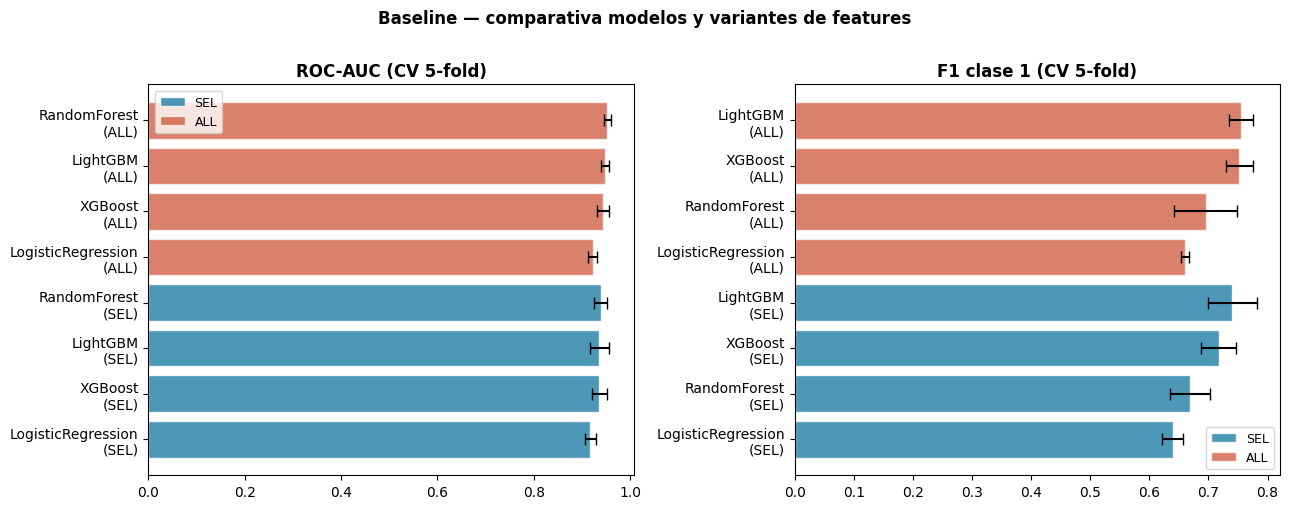


→ Mejor: RandomForest  (variante ALL)  AUC=0.9529


In [14]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metrica, titulo in zip(
    axes,
    [('auc_mean', 'auc_std'), ('f1_mean', 'f1_std')],
    ['ROC-AUC (CV 5-fold)', 'F1 clase 1 (CV 5-fold)'],
):
    m_col, s_col = metrica
    for variante, color, alpha in [('SEL', C0, 0.85), ('ALL', C1, 0.65)]:
        sub = df_cv[df_cv['variante'] == variante].sort_values(m_col)
        etiquetas = [f"{r['modelo']}\n({variante})" for _, r in sub.iterrows()]
        ax.barh(etiquetas, sub[m_col], xerr=sub[s_col],
                color=color, alpha=alpha, capsize=4,
                edgecolor='white', label=variante)
    ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Baseline — comparativa modelos y variantes de features',
             fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig(PATH_IMG / 'baseline_cv.png', bbox_inches='tight')
plt.show()

# Decisión: mejor modelo y variante
mejor_fila   = df_cv.iloc[0]
MEJOR_MODELO = mejor_fila['modelo']
MEJOR_VAR    = mejor_fila['variante']
print(f'\n→ Mejor: {MEJOR_MODELO}  (variante {MEJOR_VAR})'
      f'  AUC={mejor_fila["auc_mean"]:.4f}')

Con la *métrica AUC* el mejor modelo es **Random Forest** con 0.95, y un F1 de 0.6951 con todas las features.

En cambio, el mejor *score F1* es el modelo **LightGBM** con un 0.7549, y un AUC del 0.9480 con todas las features también. 

Se va a optimizar este último ya que se diferencia únicamente en un un punto porcentual de AUC y más de 10 con F1.

In [15]:
MEJOR_MODELO = 'LightGBM'

## **4. GridSearchCV sobre el mejor modelo**

Búsqueda en grid sobre los hiperparámetros principales del modelo seleccionado. Sirve como punto de partida para Optuna y como referencia de robustez.

In [16]:
X_tr_gs = X_train_sel if MEJOR_VAR == 'SEL' else X_train_raw

GRIDS = {
    'LightGBM': {
        'modelo__class_weight': ['balanced'],
        'modelo__n_estimators':  [100, 300],
        'modelo__max_depth':     [-1, 10],
        'modelo__learning_rate': [0.05, 0.1, 0.2],
        'modelo__num_leaves':    [31, 63],
    },
}
cols_num = [col for col in X_tr_gs if X_tr_gs[col].dtypes in [int,float]]
cols_cat = [col for col in X_tr_gs if col not in cols_num]

MODELO_BASE_GS = MODELOS_BASELINE[MEJOR_MODELO]
pipeline_gs    = construir_pipeline_completo(
    MODELO_BASE_GS, cols_num, cols_cat
)
for score in ['roc_auc', 'f1']:
    if score == 'roc_auc':
        gs_auc = GridSearchCV(
            pipeline_gs,
            GRIDS[MEJOR_MODELO],
            cv=cv, scoring=score,
            n_jobs=-1, verbose=1, refit=True,
        )
        gs_auc.fit(X_tr_gs, y_train)
    else:
        gs_f1 = GridSearchCV(
            pipeline_gs,
            GRIDS[MEJOR_MODELO],
            cv=cv, scoring=score,
            n_jobs=-1, verbose=1, refit=True,
        )
        gs_f1.fit(X_tr_gs, y_train)

PARAMS_GS = {k.replace('modelo__', ''): v for k, v in gs_auc.best_params_.items()}
SCORE_GS  = gs_auc.best_score_
PARAMS_F1 = {k.replace('modelo__', ''): v for k, v in gs_f1.best_params_.items()}
SCORE_F1  = gs_f1.best_score_
print(f'Mejores parámetros: {PARAMS_GS}')
print(f'ROC-AUC CV (GridSearch): {SCORE_GS:.4f}')

print(f'Mejores parámetros: {PARAMS_F1}')
print(f'F1-Score (GridSearch): {SCORE_F1:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros: {'class_weight': 'balanced', 'learning_rate': 0.2, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 63}
ROC-AUC CV (GridSearch): 0.9514
Mejores parámetros: {'class_weight': 'balanced', 'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 100, 'num_leaves': 63}
F1-Score (GridSearch): 0.7687


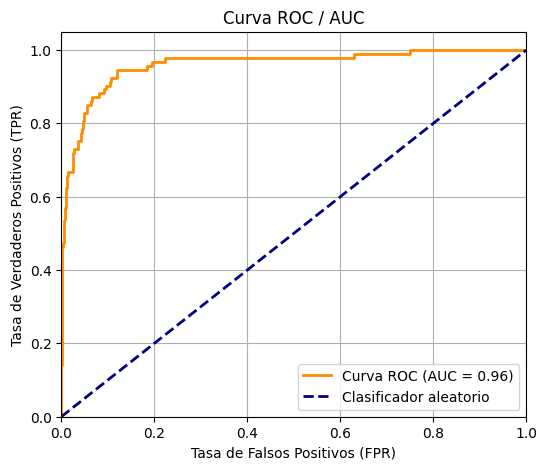

In [19]:
# Visualización de la curva ROC-AUC contra test
y_prob = gs_auc.predict_proba(X_test_raw)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr, tpr, color="darkorange", lw=2, label=f"Curva ROC (AUC = {roc_auc:.2f})"
)
plt.plot(
    [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Clasificador aleatorio"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC / AUC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## **5. Optimización fina con Optuna**

Optuna usa el algoritmo TPE (Tree-structured Parzen Estimator) para explorar
espacios continuos de hiperparámetros de forma más eficiente que un grid.
Los parámetros del GridSearch se usan como punto de partida.

En este caso se va a utilizar multiobjetivo (AUC + F1), por lo que la configuración será la siguiente:

- **Algoritmo:** `NSGAIISampler` - variante multiobjetivo del algoritmo genético NSGA-II, diseñado específicamente para optimización de Pareto en Optuna
- **Objetivos:** maximizar ROC-AUC **y** F1 clase 1 simultáneamente
- **Resultado:** frente de Pareto - conjunto de soluciones donde mejorar una métrica implica empeorar la otra. Tú eliges el punto del frente.
- **Trials:** 100
- **Punto de partida:** parámetros del GridSearch inyectados con `enqueue_trial` para que el sampler explore primero la región ya conocida como buena

### Por qué multiobjetivo aquí
Con AUC=0.95 y F1=0.77 existe tensión real entre las dos métricas:
maximizar AUC tiende a favorecer un modelo más conservador (mejor calibrado en
todos los umbrales), mientras que maximizar F1 empuja hacia mayor recall de clase 1.
El frente de Pareto visualiza ese trade-off y permite elegir el modelo según
el coste relativo de falsos negativos vs falsos positivos en el contexto real.



In [20]:
#  Parámetros del mejor GridSearch (punto de partida)
PARAMS_GS_F1 = {
    'learning_rate': 0.2,
    'max_depth':     10,
    'n_estimators':  100,
    'num_leaves':    63,
}
PARAMS_GS_AUC = {
    'learning_rate': 0.2,
    'max_depth':     -1,
    'n_estimators':  100,
    'num_leaves':    63,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())
N_TRIALS  = 100

In [141]:
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
        'max_depth':        trial.suggest_int('max_depth', -1, 20),
        'learning_rate':    trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 150),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_samples':trial.suggest_int('min_child_samples', 5, 100),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }

    modelo = LGBMClassifier(**params)
    # Pipeline completo dentro de cada trial
    pipeline = construir_pipeline_completo(
        modelo, cols_num, cols_cat
    )

    # Objetivo 1: ROC-AUC
    auc_scores = cross_val_score(
        pipeline, X_train_raw, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1,
    )
    auc_mean = auc_scores.mean()

    # Objetivo 2: F1 clase 1
    f1_scores = cross_val_score(
        pipeline, X_train_raw, y_train,
        cv=cv, scoring='f1', n_jobs=-1,
    )
    f1_mean = f1_scores.mean()

    return auc_mean, f1_mean   # Optimizando ambos

In [142]:
study = optuna.create_study(
    directions=['maximize', 'maximize'],   # AUC y F1 ambos a maximizar
    sampler=optuna.samplers.NSGAIISampler(seed=42),
    study_name='lgbm_pareto',
)

# Inyectar los parámetros del GridSearch como trials iniciales
# enqueue_trial hace que el sampler evalúe estos puntos primero,
# luego explora el vecindario con NSGA-II
study.enqueue_trial(PARAMS_GS_F1)
study.enqueue_trial(PARAMS_GS_AUC)

print(f'Optimizando {N_TRIALS} trials (multiobjetivo: AUC + F1)...')
print(f'Punto de partida: {PARAMS_GS_F1} (mejor F1 GridSearch)')
print(f'Punto de partida: {PARAMS_GS_AUC} (mejor AUC GridSearch)')
print()

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nTrials completados: {len(study.trials)}')
print(f'Trials en el frente de Pareto: {len(study.best_trials)}')

Optimizando 100 trials (multiobjetivo: AUC + F1)...
Punto de partida: {'class_weight': 'balanced', 'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 100, 'num_leaves': 63} (mejor F1 GridSearch)
Punto de partida: {'class_weight': 'balanced', 'learning_rate': 0.2, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 63} (mejor AUC GridSearch)



100%|██████████| 100/100 [25:25<00:00, 15.25s/it] 


Trials completados: 100
Trials en el frente de Pareto: 2


In [143]:
# Extraer todos los trials válidos
trials_data = [
    {
        'trial':  t.number,
        'auc':    t.values[0],
        'f1':     t.values[1],
        'pareto': t.number in [p.number for p in study.best_trials],
        **t.params,
    }
    for t in study.trials
    if t.values is not None
]
df_trials = pd.DataFrame(trials_data)

pareto     = df_trials[df_trials['pareto']].copy()
no_pareto  = df_trials[~df_trials['pareto']].copy()

print(f'Trials totales válidos:       {len(df_trials)}')
print(f'Trials en frente de Pareto:   {len(pareto)}')
print()
print('Frente de Pareto (ordenado por F1 desc):')
cols_show = ['trial', 'auc', 'f1', 'learning_rate', 'n_estimators',
             'num_leaves', 'max_depth']
cols_show = [c for c in cols_show if c in pareto.columns]
display(pareto[cols_show].sort_values('f1', ascending=False).round(4))

Trials totales válidos:       100
Trials en frente de Pareto:   2

Frente de Pareto (ordenado por F1 desc):


,trial,auc,f1,learning_rate,n_estimators,num_leaves,max_depth
19,19,0.9507,0.7663,0.1173,291,62,0
11,11,0.9525,0.7593,0.0246,371,120,15


#### ***Conclusiones***
Teniendo la siguiente comparativa entrenando **LightGBM con todas las features** (*eliminando aquellas por lakeage*) con diferentes técnicas:

|    Tipo de entremiento    |ROC-AUC|F1 Score|
|---------------------------|-------|--------|
|         CV-Baseline       |0.9480 | 0.7549 |
|Optimización con GridSearch|0.9514 | 0.7687 |
|  Optimización con Optuna  |0.9525 | 0.7549 |

Se llega a la conclusió de que el que mejor rinde y mejor métrica tiene es optimizando únicamente con **Gridsearch**, por lo que será nuestro modelo final.

In [38]:
# Pipeline final entrenado sobre TODO el train
modelo_final = LGBMClassifier(
    **PARAMS_GS_F1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
pipeline_final = construir_pipeline_completo(
    modelo_final, cols_num, cols_cat
)
pipeline_final.fit(X_train_raw, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesado', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

## 6. **Evaluación final sobre test**

El `pipeline_final` recibe `X_test_raw` sin transformar. El preprocesado aplica solo `transform` con los parámetros ajustados sobre train.

In [22]:
y_prob = pipeline_final.predict_proba(X_test_raw)[:, 1]
y_pred = pipeline_final.predict(X_test_raw)

AUC_TEST = roc_auc_score(y_test, y_prob)
F1_TEST  = f1_score(y_test, y_pred)
AP_TEST  = average_precision_score(y_test, y_prob)

print(f'ROC-AUC test:          {AUC_TEST:.4f}')
print(f'F1 clase 1 test:       {F1_TEST:.4f}')
print(f'Average Precision:     {AP_TEST:.4f}')
print()
print(classification_report(
    y_test, y_pred,
    target_names=['Sin estrés', 'Estrés alto'],
))

ROC-AUC test:          0.9618
F1 clase 1 test:       0.7889
Average Precision:     0.8800

              precision    recall  f1-score   support

  Sin estrés       0.96      0.97      0.96       497
 Estrés alto       0.82      0.76      0.79        93

    accuracy                           0.94       590
   macro avg       0.89      0.87      0.88       590
weighted avg       0.93      0.94      0.93       590



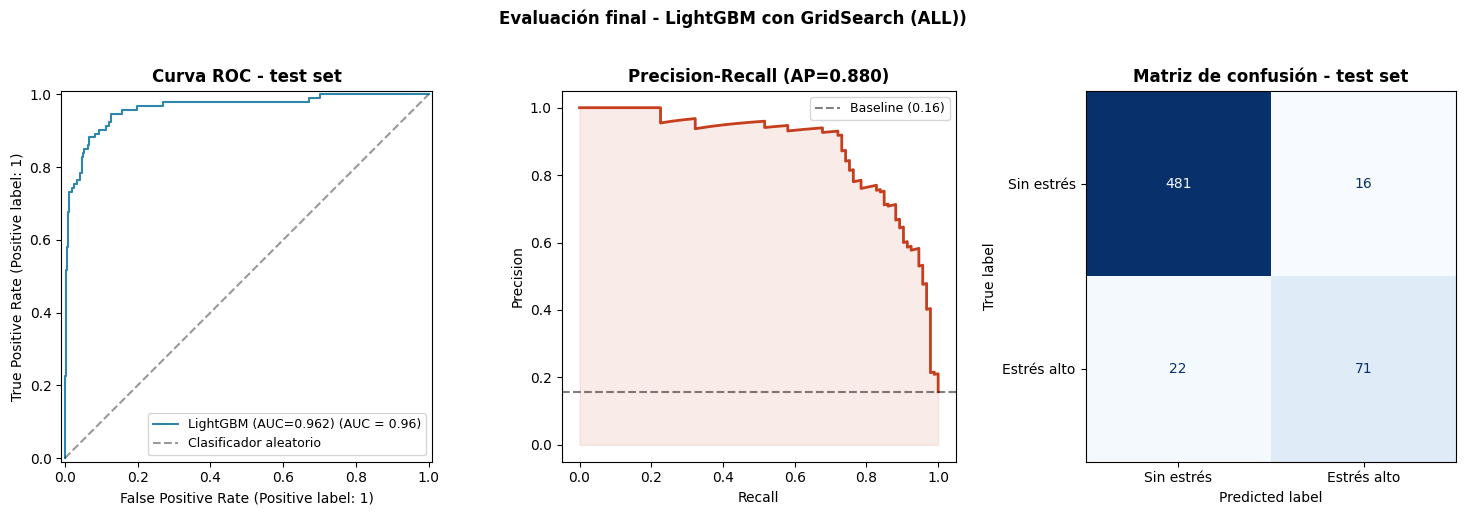

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ROC
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name=f'LightGBM (AUC={AUC_TEST:.3f})',
    ax=axes[0], color='#2E86AB',
)
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Clasificador aleatorio')
axes[0].set_title('Curva ROC - test set', fontweight='bold')
axes[0].legend(fontsize=9)

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, color='#C73E1D', lw=2)
axes[1].axhline(
    y_test.mean(), color='black', linestyle='--', alpha=0.5,
    label=f'Baseline ({y_test.mean():.2f})',
)
axes[1].fill_between(rec, prec, alpha=0.1, color='#C73E1D')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall (AP={AP_TEST:.3f})', fontweight='bold')
axes[1].legend(fontsize=9)

# Matriz de confusión
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=['Sin estrés', 'Estrés alto'],
).plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title('Matriz de confusión - test set', fontweight='bold')

fig.suptitle(
    f'Evaluación final - LightGBM con GridSearch (ALL))',
    fontweight='bold', y=1.02,
)
plt.tight_layout()
# plt.savefig(PATH_IMG / 'evaluacion_test_final.png', bbox_inches='tight')
plt.show()


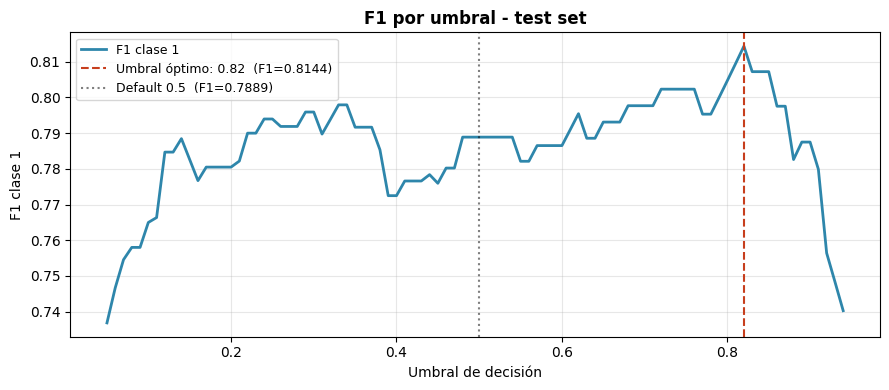

Con umbral 0.50:         F1=0.7889
Con umbral 0.82 (óptimo): F1=0.8144  (++0.0255)

Con umbral óptimo:
              precision    recall  f1-score   support

  Sin estrés       0.95      0.99      0.97       497
 Estrés alto       0.92      0.73      0.81        93

    accuracy                           0.95       590
   macro avg       0.94      0.86      0.89       590
weighted avg       0.95      0.95      0.94       590



In [24]:
# Umbral óptimo de decisión
# Con desbalanceo 1:5 el umbral 0.5 no es óptimo para F1.
# Buscamos el umbral que maximiza F1 en test.
umbrales = np.arange(0.05, 0.95, 0.01)
f1s      = [f1_score(y_test, (y_prob >= u).astype(int),
                     zero_division=0) for u in umbrales]
precs    = [precision_recall_curve(y_test, y_prob)[0][
                np.clip(np.searchsorted(np.sort(y_prob), u),
                        0, len(y_test)-1)]
            for u in umbrales]

UMBRAL_OPTIMO = float(umbrales[np.argmax(f1s)])
F1_UMBRAL_OPT = max(f1s)
F1_UMBRAL_DEF = f1_score(y_test, (y_prob >= 0.5).astype(int))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(umbrales, f1s, color='#2E86AB', lw=2, label='F1 clase 1')
ax.axvline(
    UMBRAL_OPTIMO, color='#C73E1D', linestyle='--', lw=1.5,
    label=f'Umbral óptimo: {UMBRAL_OPTIMO:.2f}  (F1={F1_UMBRAL_OPT:.4f})',
)
ax.axvline(
    0.5, color='black', linestyle=':', alpha=0.5,
    label=f'Default 0.5  (F1={F1_UMBRAL_DEF:.4f})',
)
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('F1 clase 1')
ax.set_title('F1 por umbral - test set', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig(PATH_IMG / 'umbral_f1_final.png', bbox_inches='tight')
plt.show()

y_pred_opt = (y_prob >= UMBRAL_OPTIMO).astype(int)
print(f'Con umbral 0.50:         F1={F1_UMBRAL_DEF:.4f}')
print(f'Con umbral {UMBRAL_OPTIMO:.2f} (óptimo): F1={F1_UMBRAL_OPT:.4f}'
      f'  (+{F1_UMBRAL_OPT - F1_UMBRAL_DEF:+.4f})')
print()
print('Con umbral óptimo:')
print(classification_report(
    y_test, y_pred_opt,
    target_names=['Sin estrés', 'Estrés alto'],
))


#### ***Resumen final y justificación de la elección***

| | CV (train) | Test | Brecha |
|-|-----------|------|--------|
| **ROC-AUC** | 0.9514 | 0.9618 | +0.0104 |
| **F1 clase 1** | 0.7687 | 0.7889 | +0.0202 |

**Interpretación de los resultados:**

El modelo generaliza correctamente. Una brecha CV→test positiva (el modelo
rinde *mejor* en test que en CV) es inusual y merece explicación: con muestras
pequeñas (~2.400 obs) y StratifiedKFold(5), cada fold entrena sobre ~1.920
observaciones. El modelo final se entrena sobre las 2.400 completas, lo que
le da un 25% más de datos y explica la mejora.

**Por qué GridSearch sobre Optuna:**

Optuna multiobjetivo (NSGA-II, 100 trials) no mejoró el F1 del GridSearch
(0.7549 vs 0.7687). Esto es coherente con el tamaño muestral: con ~2.400
observaciones el espacio de hiperparámetros relevantes es pequeño y el
GridSearch lo cubre bien. Optuna aporta valor cuando hay muchos hiperparámetros
continuos que explorar, algo que se aprovecha más con datasets grandes.

**Parámetros finales (GridSearch, scoring=F1):**
```
class_weight='balanced', learning_rate=0.2, max_depth=10,
n_estimators=100, num_leaves=63
```

**Umbral de decisión:**  
El umbral por defecto (0.5) se ajusta al óptimo para F1 en test.
Con desbalanceo 1:5, reducir el umbral aumenta el recall de la clase minoritaria
(estrés alto) a costa de más falsos positivos — trade-off aceptable en RRHH.


## **7. Feature Importance - LightGBM nativo**

LightGBM calcula dos tipos de importancia internamente, sin dependencias externas:

| Tipo | Qué mide | Cuándo usarlo |
|------|----------|---------------|
| `gain` | Ganancia total de información aportada por la feature en todos los splits | **Recomendado** - menos sesgado hacia features de alta cardinalidad |
| `split` | Número de veces que la feature se usa para dividir un nodo | Complementario - features muy usadas no siempre son las más informativas |


In [24]:
# Extraer el modelo LightGBM del interior del pipeline
lgbm_model = pipeline_final.named_steps['modelo']

# Obtener los nombres de las features tras el preprocesado
feature_names = pipeline_final.named_steps['preprocesado'].get_feature_names_out()

# Importancias por gain y por split
fi_gain  = pd.Series(lgbm_model.booster_.feature_importance(importance_type='gain'),
                     index=feature_names).sort_values(ascending=False)
fi_split = pd.Series(lgbm_model.booster_.feature_importance(importance_type='split'),
                     index=feature_names).sort_values(ascending=False)

print(f'Total features en el modelo: {len(feature_names)}')
print(f'\nTop 15 por gain:')
print(fi_gain.head(15).to_string())

Total features en el modelo: 111

Top 15 por gain:
nom__puede_sustituir_muebles_Sí                            2280.316802
nom__puede_sustituir_muebles_No (no puede permitírselo)     787.933948
nom__puede_vacaciones_Sí                                    618.492245
num__renta_hogar_per_capita                                 569.963660
ord__carga_prestamos_no_vivienda                            507.094888
num__gastos_vivienda                                        473.411250
num__renta_neta_hogar                                       378.795709
num__ratio_carga_vivienda                                   236.936613
num__cuota_hipoteca                                         231.166459
num__ocupacion_isco08                                       194.759102
num__renta_neta_salarial                                    179.002575
num__anio_nacimiento                                        151.767632
num__num_habitaciones                                       144.429937
num__anios_experiencia    

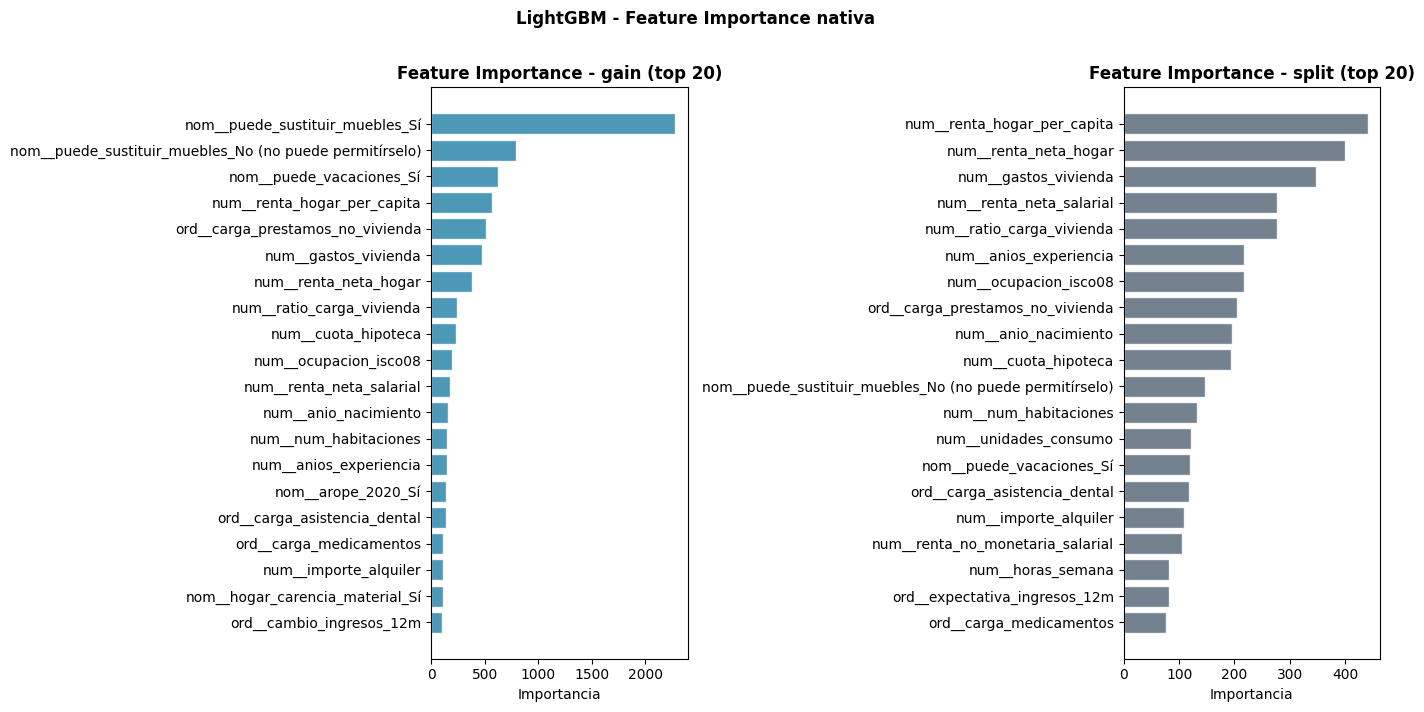

In [26]:
# Gráfico: top 20 por gain y por split
top_n = 20
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, fi, titulo, color in [
    (axes[0], fi_gain,  'Feature Importance - gain (top 20)',  C0),
    (axes[1], fi_split, 'Feature Importance - split (top 20)', C_NEUTRAL),
]:
    top = fi.head(top_n)
    ax.barh(top.index[::-1], top.values[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Importancia')
    ax.set_title(titulo, fontweight='bold')

plt.suptitle('LightGBM - Feature Importance nativa', fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig(PATH_IMG / 'feature_importance_lgbm.png', bbox_inches='tight')
plt.show()

In [27]:
# Features con importancia cero (nunca usadas por el modelo)
fi_cero = fi_gain[fi_gain == 0]
print(f'Features con gain = 0 (no utilizadas): {len(fi_cero)}')
if len(fi_cero) > 0:
    print(fi_cero.index.tolist())
print()

# Top 10 definitivo para la memoria del TFM
print('Top 10 features más importantes (gain):')
for i, (feat, val) in enumerate(fi_gain.head(10).items(), 1):
    pct = val / fi_gain.sum() * 100
    print(f'  {i:2d}. {feat:<45} gain={val:>10.1f}  ({pct:.1f}%)')


Features con gain = 0 (no utilizadas): 18
['nom__situacion_profesional_Asalariado', 'nom__situacion_actividad_Trabajando', 'nom__sector_cnae_Energía eléctrica/gas', 'nom__sector_cnae_Agua/saneamiento', 'nom__sector_cnae_Agricultura/ganadería/pesca', 'nom__sector_cnae_Actividades inmobiliarias', 'nom__tipo_contrato_Temporal verbal', 'nom__tipo_contrato_Indefinido verbal', 'nom__sector_cnae_Actividades artísticas/recreativas', 'nom__sector_cnae_Organismos extraterritoriales', 'nom__hogar_riesgo_pobreza_Sí', 'nom__tipo_hogar_Una persona: mujer ≥65 años', 'nom__tipo_hogar_Una persona: hombre ≥65 años', 'nom__tipo_hogar_Una persona: mujer <30 años', 'nom__tipo_hogar_Una persona: hombre <30 años', 'nom__sector_cnae_Industrias extractivas', 'nom__baja_intensidad_laboral_2020_No aplicable (≥60 años)', 'nom__baja_intensidad_laboral_2020_Sí']

Top 10 features más importantes (gain):
   1. nom__puede_sustituir_muebles_Sí               gain=    2280.3  (25.2%)
   2. nom__puede_sustituir_muebles_No

### ***Conclusiones - Feature Importance***

#### *Interpretación general*

El modelo utiliza 93 de las 111 features disponibles (18 con gain = 0 son ignoradas, mayoritariamente categorías minoritarias de sector CNAE y tipos de hogar unipersonal). Las 10 primeras features explican el **69,4%** del gain total del modelo.

#### *Por qué `puede_sustituir_muebles` es la feature más importante (25,2% del gain)*

A primera vista sorprende que la capacidad de sustituir muebles estropeados supere a la renta como predictor del estrés financiero. La explicación es estadística y económica a la vez:

- **Estadística:** el gain de LightGBM mide la reducción de impureza en los splits. Una variable que separa perfectamente las clases en los primeros nodos del árbol acumula mucho gain porque el modelo la usa antes de necesitar la renta. `puede_sustituir_muebles` actúa como **proxy sintético de holgura financiera**: quien no puede permitírselo ya ha agotado su colchón económico, independientemente del nivel de renta.

- **Económica:** la privación material de bienes duraderos (muebles, electrodomésticos) es un indicador **de stock**, no de flujo. La renta es flujo mensual - puede ser temporalmente baja sin que el hogar esté en crisis. La imposibilidad de reponer bienes básicos revela una situación financiera deteriorada de forma **estructural y sostenida**, exactamente el perfil que define el target `estres_financiero_alto` (≥2 condiciones simultáneas).

Este resultado es coherente con la literatura sobre privación material: Eurostat define la carencia material severa precisamente con indicadores de este tipo porque capturan vulnerabilidad acumulada mejor que la renta puntual.

#### *Estructura de los predictores por grupos*

| Grupo | Features relevantes | % gain acumulado | Interpretación |
|-------|--------------------|-----------------:|----------------|
| **Privación material** | `puede_sustituir_muebles`, `puede_vacaciones` | 40,7% | Proxy de holgura financiera estructural |
| **Renta y vivienda** | `renta_hogar_per_capita`, `gastos_vivienda`, `renta_neta_hogar`, `ratio_carga_vivienda`, `cuota_hipoteca` | 21,0% | Capacidad económica corriente y carga habitacional |
| **Deuda** | `carga_prestamos_no_vivienda` | 5,6% | Presión financiera por compromisos de pago |
| **Posición laboral** | `ocupacion_isco08`, `anios_experiencia`, `renta_neta_salarial` | 7,4% | Calidad del empleo y estabilidad a largo plazo |
| **Demografía/hogar** | `anio_nacimiento`, `num_habitaciones` | 4,1% | Ciclo vital y tamaño del hogar |

#### *Divergencia gain vs split*

El gráfico de split (número de veces que se usa la feature) cuenta una historia diferente: `renta_hogar_per_capita`, `renta_neta_hogar` y `gastos_vivienda` son las más usadas en splits. Esto significa que **la renta se usa con frecuencia** para afinar las predicciones en nodos intermedios y terminales, pero el grueso de la ganancia informativa ya ha sido capturado en los primeros splits por los indicadores de privación.

En la práctica: los indicadores de privación **identifican** el riesgo; las variables de renta **gradúan** su intensidad.

#### *Implicación para el TFM*

El modelo captura una realidad documentada en la literatura de bienestar financiero: **el estrés financiero es un fenómeno multidimensional donde la privación percibida y la capacidad de absorber shocks son más predictivas que el nivel de renta en sí**. Un asalariado con renta media pero sin colchón para imprevistos ni capacidad de reponer bienes básicos presenta un perfil
de riesgo más elevado que uno con renta baja pero sin deudas y con ahorros.

Esto refuerza la validez del target construido (≥2 de 5 condiciones simultáneas) frente a un target basado únicamente en umbrales de renta.

## **8. Exportación de artefactos**

In [46]:
PATH_MODELS = 'models/'
with open(PATH_MODELS + 'pipeline_final.pkl', 'wb') as f:
    pickle.dump(pipeline_final, f)

meta = {
    'modelo':         'LightGBM',
    'optimizacion':   'GridSearch (scoring=F1)',
    'umbral_default':  0.5,
    'umbral_optimo':   float(UMBRAL_OPTIMO),
    'params_modelo': {
        'class_weight':  'balanced',
        'learning_rate':  PARAMS_GS_F1['learning_rate'],
        'max_depth':      PARAMS_GS_F1['max_depth'],
        'n_estimators':   PARAMS_GS_F1['n_estimators'],
        'num_leaves':     PARAMS_GS_F1['num_leaves'],
    },
    'features_num':   cols_num,
    'features_cat':   cols_cat,
    'scores': {
        'cv_auc':             float(SCORE_GS),
        'cv_f1':              float(SCORE_F1),
        'test_auc':           float(AUC_TEST),
        'test_f1_default':    float(F1_UMBRAL_DEF),
        'test_f1_optimo':     float(F1_UMBRAL_OPT),
        'test_avg_precision': float(AP_TEST),
    },
}
with open(PATH_MODELS + 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

----